/tmp/ipykernel_1021960/701242849.py:22: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  resources = pd.read_csv(file, delimiter=", ")
/tmp/ipykernel_1021960/701242849.py:22: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  resources = pd.read_csv(file, delimiter=", ")
/tmp/ipykernel_1021960/701242849.py:158: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  lat.legend(loc='upper left')


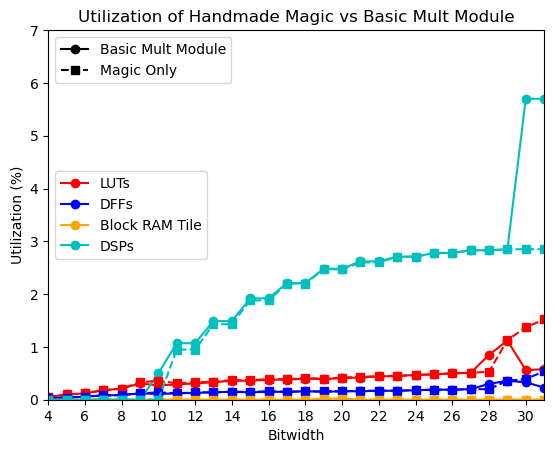

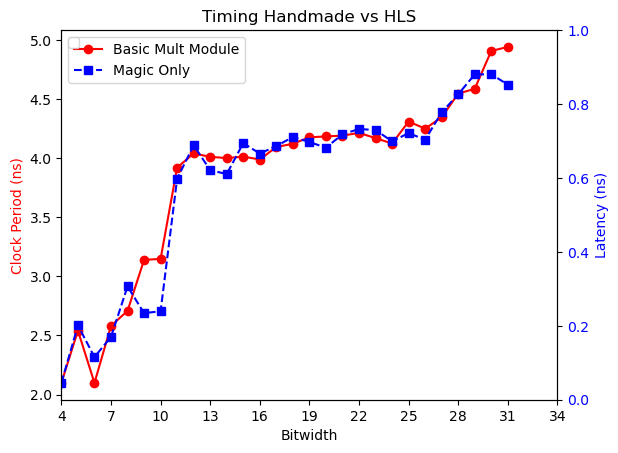

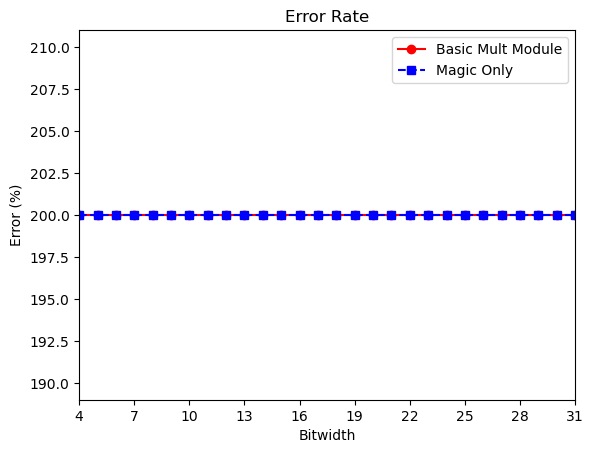

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
legend_lines = []
# hand_lat = [23, 19, 16]
resf, res = plt.subplots()

timingf, timing = plt.subplots()

accf, acc = plt.subplots()
# latf, lat = plt.subplots()
lat = timing.twinx()

marker_styles = [None,'o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', '|', '_']
line_styles = ['-', '--', '-.', ':']
colors = ['r','b',(255.0/255,165.0/255,0),'c','m','g']
j=[0, 1]
timings = []
renames = {"Slice Registers":"DFFs", "Slice LUTs":"LUTs"}
# colorkey = {"LUTs":'r', "DFFs": 'y', "DSPs": }
def plot_res(file, ls, name, marker, color_sel=None):
    resources = pd.read_csv(file, delimiter=", ")
    x_val = resources["Bits"]
    all_res_hand = []
    Nono = "Bits Accuracy Timing Bonded IOB CycleLatency TotalLatency BlockRAMTile"
    i=0
    # timings.append((resources["Timing"], name))
    timing.plot(x_val, 5-resources["Timing"], label=name, linestyle=ls, color=colors[j[0]], marker=marker)
    acc.plot(x_val, (1-resources["Accuracy"])*100, label=name, linestyle=ls, color=colors[j[0]], marker=marker)
    j[0]=(j[0]+1)%len(colors)
    for key in resources:
        if (key not in Nono):
            all_res_hand.append(resources[key])
            nam = key if key not in renames else renames[key]
            res.plot(x_val, 
            resources[key], 
            label=(nam if len(legend_lines)==0  else None), 
            linestyle=ls, 
            color=colors[i%len(colors)] if color_sel==None else color_sel,
            marker=marker)
            i+=1
            
    legend_lines.append((name, ls, marker,color_sel))
cycle_ii_hand = 141
cycle_lat_hand = cycle_ii_hand+13
# plot_res(f"handmade/Results/util_SA3.csv", line_styles[0], 
# f"Depth 3.0",marker_styles[0]
# )
# for i in range(2,10,2):
#     i_linestyle=(int(i/2))%len(line_styles)
#     i_marker=int((int(i/2))/len(line_styles))
#     plot_res(f"handmade/Results/util_SA3_{i}.csv", 
#     line_styles[i_linestyle], 
#     f"Depth 3.{i}",
#     marker_styles[i_marker]
#     # ,colors[(int((i)/2))%len(colors)]
#     )
# plot_res(f"handmade/Results/util_SA4.csv", line_styles[2], f"Depth 4.0",marker_styles[1]
# )
# plot_res("handmade/Results/util_Argmax_varpipes.csv", '-', "Optimized SA",marker_styles[0] )
# plot_res("handmade/Results/util_perf.csv", '--', "Old Optimized SA",marker_styles[0] )
# plot_res("handmade/Results/util_Argmax_pipe3PO0.csv", '-', "pipe3",marker_styles[0] )
# plot_res("handmade/Results/util_Argmax_P1_PO0_SA2_MULTPIPE1.csv", '-', "M1",marker_styles[1] )
# plot_res("handmade/Results/util_Argmax_P1_PO0_SA2_MULTPIPE.csv", '-.', "M0",marker_styles[1] )
# plot_res("LSTM-Handmade/Results/util_SecondToptag.csv", '-', "Handmade",marker_styles[1] )
# plot_res("LSTM-Handmade/Results/util_Toptag_BJT_SA.csv", '--', "Handmade",marker_styles[1] )
# plot_res("results/util_onelayerNoMagic.csv", '-', "Plain mult",marker_styles[1] )
plot_res("results/util_onelayerBasicWidthpNfrac.csv", '-', "Basic Mult Module",marker_styles[1] )
plot_res("results/util_magicOnly.csv", '--', "Magic Only",marker_styles[2] )
# plot_res("results/util_onelayer.csv", '-.', "Magic Mult",marker_styles[3] )
# plot_res("LSTM-hls/results/util_hls_iitest.csv", '--', "HLS",marker_styles[2] )
# hls_res = pd.read_csv("LSTM-hls/results/util_hls_iitest.csv", delimiter=", ")
# for i in range(len(hls_res["Timing"])):
#     hls_res["Timing"][i]=np.round(10-hls_res["Timing"][i],6)
# hls_res.to_csv("LSTM-hls/results/util_hls_iitest.csv")
# plot_res("handmade/Results/util_MinpipeNegmax.csv", '--', "noexppipe",marker_styles[1] )
# plot_res("handmade/Results/util_Argmax_P1_PO1.csv", ':', "pipe1po1",marker_styles[1] )
# plot_res("handmade/Results/util_Argmax_P1_PO0_SA2.csv", ":","NORM", marker_styles[0])
# plot_res("hls4ml/results/util_hls_please.csv", ':', "HLS4ML",marker_styles[3] )
# plot_res("hls4ml/results/util_hls_reuse5.csv", '-', "HLS4ML R5",marker_styles[3] )
# plot_res("../util_norm_op.csv", ':', "Op norm")
# plot_res("../Results/util_SA2.csv", '-.', "SA2",marker_styles[0])
# plot_res("handmade/Results/util_SA2.csv", '-.', "SA2", marker_styles[0])
#plot_res("../util_SA4.csv", '--', "SA4",marker_styles[0])
#plot_res("../util_SA6.csv", '-', "SA6",marker_styles[4])
# plot_res("../util_SA3_6.csv", ':', "SA3.6",marker_styles[1])
# plot_res("../util_SA3_8.csv", '--', "SA3.8",marker_styles[1])
# plot_res("../util_SA4.csv", '-', "SA4",marker_styles[1])
#plot_res("../util_SA6.csv", ':', "SA6")
# plot_res("../Results/util_unop.csv", ':', "Handmade", marker_styles[0])
# plot_res("util_hls_new.csv", '--', "HLS4ML", marker_styles[0])
# plot_res("util_hls_fast.csv", '-.', "HLS4ML fast", marker_styles[0])
# plot_res("util_hls_final.csv", ':', "HLS4ML final", marker_styles[0])
# plot_res("util_hls_argmax.csv", '-', "HLS4ML argmax", marker_styles[0])
# latency = pd.read_csv("hls4ml/results/hls_latency.csv", delimiter = ", ")["Lat"]
# # print(latency)
# csv_val = pd.read_csv("hls4ml/results/util_hls_please.csv")
# total_latency= csv_val["TotalLatency"]
# txval = csv_val["Bits"]
# timingHLS = csv_val["Timing"]
# total_period_hls = np.add(5, -timingHLS)
# timing.plot(txval, total_period_hls, marker=marker_styles[4], linestyle='--', color = 'r')

# total_period = np.add(5, -tim)
# total_latency = np.multiply(latency, total_period)

# lat.plot(txval, total_latency, label="HLS4ML", marker=marker_styles[4], linestyle='--', color = 'b')

# hand = pd.read_csv("handmade/Results/util_expPipeNegmax.csv")
# timinghand = hand["Timing"]
# total_period_hand = np.add(5, -timinghand)
# timing.plot(hand["Bits"], total_period_hand, marker=marker_styles[1], linestyle='-', color = 'r')
# txval = hand["Bits"]

# totaltHand = np.multiply(total_period_hand, hand["CycleLatency"])
# lat.plot(txval[:len(totaltHand)], totaltHand, label="Handmade", marker=marker_styles[1], linestyle='-', color = 'b')

# txval = pd.read_csv("handmade/Results/util_expPipeNegmax.csv")["Bits"]
# timinghand = pd.read_csv("handmade/Results/util_expPipeNegmax.csv")[" Timing"]
# total_period_hand = np.add(5, -timinghand)
# totaltHand = np.multiply(total_period_hand, 11)
# lat.plot(txval[:len(totaltHand)], totaltHand, label="NEG")

# txval = pd.read_csv("handmade/Results/util_Argmax_P1_PO0_SA2_MULTPIPE.csv")["Bits"]
# timinghand = pd.read_csv("handmade/Results/util_Argmax_P1_PO0_SA2_MULTPIPE.csv")[" Timing"]
# total_period_hand = np.add(5, -timinghand)
# totaltHand = np.multiply(total_period_hand, 9)
# lat.plot(txval[:len(totaltHand)], totaltHand, label="Pipe3po0")

# txval = pd.read_csv("handmade/Results/util_Argmax_pipe3.csv")["Bits"]
# timinghand = pd.read_csv("handmade/Results/util_Argmax_pipe3PO1.csv")[" Timing"]
# total_period_hand = np.add(5, -timinghand)
# totaltHand = np.multiply(total_period_hand, 13)
# lat.plot(txval[:len(totaltHand)], totaltHand, label="Pipe3po1")


# total_latency_hand = []
# total_ii_hand = []
# timing_hand = pd.read_csv("LSTM-Handmade/Results/util_Toptag_reduced_cycles.csv", delimiter=", ")["Timing"]
# bits  = pd.read_csv("LSTM-Handmade/Results/util_Toptag_reduced_cycles.csv", delimiter=", ")["Bits"]
# for tim in timing_hand:
#     tim_f = 10-float(tim)
#     total_latency_hand.append(tim_f*cycle_lat_hand)
#     total_ii_hand.append(tim_f*cycle_ii_hand)
# print(total_latency_hand)
# lat.plot(bits, total_latency_hand, label="Handmade", color = 'b',marker=marker_styles[1])
# timing.plot(bits, total_ii_hand, label="Handmade", color = 'r',marker=marker_styles[1])

# bits  = pd.read_csv("LSTM-hls/results/util_hls_iitest.csv", delimiter=", ")["Bits"]
# total_latency_hls = pd.read_csv("LSTM-hls/results/util_hls_iitest.csv", delimiter=", ")["Total Latency"]
# total_ii_hls = pd.read_csv("LSTM-hls/results/util_hls_iitest.csv", delimiter=", ")["Total II"]
# lat.plot(bits, total_latency_hls, label="HLS", color = 'b', linestyle='--',marker=marker_styles[2])
# timing.plot(bits, total_ii_hls, label="HLS", color = 'r', linestyle='--',marker=marker_styles[2])
# timing.tick_params(axis='y', labelcolor='r')

#print()

lat.legend(loc='upper left')
lat.set_xticks(np.arange(4, 40, 3))
lat.set_ylim(0)
lat.set_xlim((4,34))
# lat.set_title("Total Latency")
# lat.set_xlabel("Bitwidth")
lat.set_ylabel("Latency (ns)", color='b')
lat.tick_params(axis='y', labelcolor='b')

timing.legend(loc='upper left')
timing.set_title("Timing Handmade vs HLS")
timing.set_xlabel("Bitwidth")
timing.set_ylabel("Clock Period (ns)", color='r')
# timing.set_ylim((0,15))
timing.set_xticks(np.arange(4, 40, 3))
timing.set_xlim((4,34))




first_legend = res.legend(loc='center left')
res.add_artist(first_legend)
lines = []
for line in legend_lines:
    l, = res.plot([], label=line[0], linestyle=line[1], marker=line[2], color=line[3] if line[3]!=None else (0,0,0))
    lines.append(l)
res.legend(handles=lines, loc='upper left')
res.set_title("Utilization of Handmade Magic vs Basic Mult Module")
res.set_xticks(np.arange(4, 40, 2))
res.set_xlim((4,31))
res.set_ylim((0,7))
res.set_xlabel("Bitwidth")
res.set_ylabel("Utilization (%)")


acc.legend(loc='upper right')
acc.set_title("Error Rate")
acc.set_xlabel("Bitwidth")
acc.set_ylabel("Error (%)")
acc.set_xticks(np.arange(4, 40, 3))
acc.set_xlim((4,31))



plt.show()
